## 1.1 Данные по диаметрам узелков

In [1]:
from collections import namedtuple
import functools
import glob
import os
import csv

CandidateInfoTuple = namedtuple(
    'CandidateInfoTuple',
    'isNodule_bool, diameter_mm, series_uid, center_xyz'
)

@functools.lru_cache(1)
def getCandidateInfoList(requireOnDist: bool = True):
    mhd_list = glob.glob('./luna16/subset*/*.mhd')
    presentOnDisk = {os.path.split(p)[-1][:-4] for p in mhd_list}

    # группировка по series_uid
    diameter_dict = {}
    with open('./luna16/annotations.csv', 'r') as f:
        for row in list(csv.reader(f))[1:]:
            series_uid = row[0]
            annotationCenter_xyz = tuple([float(x) for x in row[1:4]])
            annotationDiameter = float(row[4])

            diameter_dict.setdefault(series_uid, []).append((annotationCenter_xyz, annotationDiameter))

    candidatesInfo = []
    with open('./luna16/candidates.csv', 'r') as f:
        for row in list(csv.reader(f))[1:]:
            series_uid = row[0]

            if series_uid not in presentOnDisk and requireOnDist:
                continue

            isNodule = bool(int(row[4]))
            candidateCenter_xyz = tuple([float(x) for x in row[1:4]])

            candidateDiameter_mm = 0.0
            for annotation in diameter_dict.get(series_uid, []):
                annotationCenter_xyz, annotationDiameter_mm = annotation
                for i in range(3):
                    delta_mm = abs(annotationCenter_xyz[i] - candidateCenter_xyz[i])

                    # радиус делённый напополам для проверки, что две точки узелка не находятся слишком далеко друг от друга
                    if delta_mm > annotationDiameter_mm / 4:
                        break
                    else:
                        candidateDiameter_mm = annotationDiameter_mm
                        break

            candidatesInfo.append(CandidateInfoTuple(isNodule, candidateDiameter_mm, series_uid, candidateCenter_xyz))

    candidatesInfo.sort(reverse=True) # начиная с самого крупного, а в конце данные, не содержащие информацию о размере
    return candidatesInfo

candidates = getCandidateInfoList()
print(len(candidates))
print(candidates[0])

551065
CandidateInfoTuple(isNodule_bool=True, diameter_mm=32.27003025, series_uid='1.3.6.1.4.1.14519.5.2.1.6279.6001.287966244644280690737019247886', center_xyz=(75.7212243102, 92.8873310394, -119.270564052))


## 1.2 Загрузка сканов

In [2]:
import SimpleITK as sitk
import numpy as np

class Ct:
    def __init__(self, series_uid):
        mhd_path = glob.glob(f'./luna16/subset*/{series_uid}.mhd')[0]
        
        ct_mhd = sitk.ReadImage(mhd_path) # неявно на вход берётся также .raw файл
        ct_a = np.array(sitk.GetArrayFromImage(ct_mhd), dtype=np.float32)
        
        ct_a.clip(-1000, 1000, ct_a) # менее -1000 это воздух и мнее плотное, >1000 это кости и более плотное

        self.series_uid = series_uid
        self.hu_a = ct_a

        self.origin_xyz = XyzTuple(*ct_mhd.GetOrigin()) # начало координат в системе отсчёта пациента
        self.vxSize_xyz = XyzTuple(*ct_mhd.GetSpacing()) # размер вокселя
        self.direction_a = np.array(ct_mhd.GetDirection()).reshape(3, 3) # матрица направления (например, если срезы идут под углом)

    def getRawCandidate(self, center_xyz, width_irc):
        '''Получение кубической области размером width_irc вокруг кандидата center_xyz, а также центр, преобразованный в систему массива'''
        center_irc = xyz2irc(center_xyz, self.origin_xyz, self.vxSize_xyz, self.direction_a)
        slice_list = []
        for axis, center_val in enumerate(center_irc):
            start_ndx = int(round(center_val) - width_irc[axis]/2)
            end_ndx = int(start_ndx + width_irc[axis])
            slice_list.append(slice(start_ndx, end_ndx))

        ct_chunk = self.hu_a[tuple(slice_list)]

        return ct_chunk, center_irc

        

## 1.3 Преобразование XYZ в IRC

In [3]:
IrcTuple = namedtuple('IrcTuple', ['index', 'row', 'col'])
XyzTuple = namedtuple('XyzTuple', ['x', 'y', 'z'])

def irc2xyz(coord_irc, origin_xyz, vxSize_xyz, direction_a):
    cri_a = np.array(coord_irc)[::-1]
    origin_a = np.array(origin_xyz)
    vxSize_a = np.array(vxSize_xyz)
    coords_xyz = (direction_a @ (cri_a * vxSize_a)) + origin_a
    return XyzTuple(*coords_xyz)

def xyz2irc(coord_xyz, origin_xyz, vxSize_xyz, direction_a):
    origin_a = np.array(origin_xyz)
    vxSize_a = np.array(vxSize_xyz)
    coord_a = np.array(coord_xyz)
    cri_a = ((coord_a - origin_a) @ np.linalg.inv(direction_a)) / vxSize_a
    cri_a = np.round(cri_a)
    return IrcTuple(int(cri_a[2]), int(cri_a[1]), int(cri_a[0]))

## 1.4 Создание реализации LunaDataset

### Логирование

In [4]:
from util.logconf import logging

log = logging.getLogger(__name__)
# log.setLevel(logging.WARN)
# log.setLevel(logging.INFO)
log.setLevel(logging.DEBUG)

### Кеширование

In [5]:
import gzip
from io import BytesIO
from diskcache import FanoutCache, Disk

BytesType = bytes
MODE_BINARY = 2

class GzipDisk(Disk):
    def store(self, value, read, key=None):
        # pylint: disable=unidiomatic-typecheck
        if type(value) is BytesType:
            if read:
                value = value.read()
                read = False

            str_io = BytesIO()
            gz_file = gzip.GzipFile(mode='wb', compresslevel=1, fileobj=str_io)

            for offset in range(0, len(value), 2**30):
                gz_file.write(value[offset:offset+2**30])
            gz_file.close()

            value = str_io.getvalue()

        return super(GzipDisk, self).store(value, read)


    def fetch(self, mode, filename, value, read):
        value = super(GzipDisk, self).fetch(mode, filename, value, read)

        if mode == MODE_BINARY:
            str_io = BytesIO(value)
            gz_file = gzip.GzipFile(mode='rb', fileobj=str_io)
            read_csio = BytesIO()

            while True:
                uncompressed_data = gz_file.read(2**30)
                if uncompressed_data:
                    read_csio.write(uncompressed_data)
                else:
                    break

            value = read_csio.getvalue()

        return value

def getCache(scope_str):
    return FanoutCache('./cache/' + scope_str,
                       disk=GzipDisk,
                       shards=64,
                       timeout=1,
                       size_limit=3e11,
                       # disk_min_file_size=2**20,
                       )

raw_cache = getCache('luna16_cache_raw')

### Загрузчик

In [6]:
import torch
from torch.utils.data import Dataset
import copy

@functools.lru_cache(1, typed=True)
def getCt(series_uid):
    return Ct(series_uid)
    
@raw_cache.memoize(typed=True)
def getCtRawCandidate(series_uid, center_xyz, width_irc):
    ct = getCt(series_uid)
    ct_chunk, center_irc = ct.getRawCandidate(center_xyz, width_irc)
    return ct_chunk, center_irc
    
class LunaDataset(Dataset):
    def __init__(self, val_stride=0, isValSet_bool=None, series_uid=None):
        '''isValSet_bool обозначает необходимость хранения только обучающих, проверочных или всех'''
        self.candidateInfo_list = copy.copy(getCandidateInfoList())

        if series_uid:
            self.candidateInfo_list = [
                x for x in self.candidateInfo_list if x.series_uid == series_uid
            ]

        if isValSet_bool:
            assert val_stride > 0, val_stride
            self.candidateInfo_list = self.candidateInfo_list[::val_stride]
            assert self.candidateInfo_list
        elif val_stride > 0:
            del self.candidateInfo_list[::val_stride]
            assert self.candidateInfo_list

        log.info("{!r}: {} {} samples".format(
            self,
            len(self.candidateInfo_list),
            "validation" if isValSet_bool else "training",
        ))
    
    def __len__(self):
        return len(self.candidateInfo_list)

    def __getitem__(self, ndx):
        candidateInfo_tup = self.candidateInfo_list[ndx]
        width_irc = (32, 48, 48)

        # получение кортежа вокруг точки
        candidate_a, center_irc = getCtRawCandidate(
            candidateInfo_tup.series_uid,
            candidateInfo_tup.center_xyz,
            width_irc,
        )

        # преобраование в torch типы
        candidate_t = torch.from_numpy(candidate_a)
        candidate_t = candidate_t.to(torch.float32)
        candidate_t = candidate_t.unsqueeze(0)

        # варианты классификации (узелок или нет)
        pos_t = torch.tensor(
            [not candidateInfo_tup.isNodule_bool, candidateInfo_tup.isNodule_bool], 
            dtype=torch.long
        )
        
        return (
            candidate_t,
            pos_t,
            candidateInfo_tup.series_uid,
            torch.tensor(center_irc),
        )        

In [7]:
#LunaDataset()[0]

2026-05-06 18:52:34,046 INFO     pid:28969 __main__:033:__init__ <__main__.LunaDataset object at 0x7c23d9cd5fd0>: 551065 training samples


(tensor([[[[-880., -846., -825.,  ..., -812., -772., -723.],
           [-862., -805., -813.,  ..., -833., -829., -801.],
           [-795., -770., -819.,  ..., -830., -808., -804.],
           ...,
           [-859., -858., -882.,  ...,  -35.,   -4.,   11.],
           [-883., -878., -876.,  ...,    0.,  -13.,  -35.],
           [-878., -845., -816.,  ...,    2.,  -15.,  -38.]],
 
          [[-924., -914., -879.,  ..., -794., -732., -638.],
           [-897., -881., -858.,  ..., -821., -787., -741.],
           [-884., -877., -875.,  ..., -824., -808., -811.],
           ...,
           [-891., -868., -784.,  ...,  -80.,  -99., -109.],
           [-887., -856., -759.,  ...,  -69.,  -83.,  -84.],
           [-884., -835., -766.,  ..., -103., -102., -100.]],
 
          [[-843., -843., -857.,  ..., -846., -837., -857.],
           [-862., -854., -864.,  ..., -844., -821., -831.],
           [-861., -843., -831.,  ..., -815., -807., -816.],
           ...,
           [-857., -789., -707.

## 1.5 Отображение данных

In [8]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

clim = (-1000.0, 300)


def _imshow(ax, img):
    ax.imshow(img, vmin=clim[0], vmax=clim[1], cmap='gray')


def _style_ticks(ax, fontsize=20):
    for label in (ax.get_xticklabels() + ax.get_yticklabels()):
        label.set_fontsize(fontsize)


def findPositiveSamples(start_ndx=0, limit=100):
    ds = LunaDataset()
    positiveSample_list = []
    for sample_tup in ds.candidateInfo_list:
        if sample_tup.isNodule_bool:
            print(len(positiveSample_list), sample_tup)
            positiveSample_list.append(sample_tup)
        if len(positiveSample_list) >= limit:
            break
    return positiveSample_list


def showCandidate(series_uid, batch_ndx=None, **kwargs):
    ds = LunaDataset(series_uid=series_uid, **kwargs)
    pos_list = [i for i, x in enumerate(ds.candidateInfo_list) if x.isNodule_bool]

    if batch_ndx is None:
        if pos_list:
            batch_ndx = pos_list[0]
        else:
            print("Warning: no positive samples found; using first negative sample.")
            batch_ndx = 0

    ct = Ct(series_uid)
    ct_t, pos_t, series_uid, center_irc = ds[batch_ndx]
    ct_a = ct_t[0].numpy()

    fig = plt.figure(figsize=(30, 50))
    group_list = [
        [9, 11, 13],
        [15, 16, 17],
        [19, 21, 23],
    ]
    nrows = len(group_list) + 2

    # Первая строка — срезы полного объёма КТ по центру узелка
    ax = fig.add_subplot(nrows, 3, 1)
    ax.set_title('index {}'.format(int(center_irc[0])), fontsize=30)
    _style_ticks(ax)
    _imshow(ax, ct.hu_a[int(center_irc[0])])

    ax = fig.add_subplot(nrows, 3, 2)
    ax.set_title('row {}'.format(int(center_irc[1])), fontsize=30)
    _style_ticks(ax)
    _imshow(ax, ct.hu_a[:, int(center_irc[1])])
    ax.invert_yaxis()

    ax = fig.add_subplot(nrows, 3, 3)
    ax.set_title('col {}'.format(int(center_irc[2])), fontsize=30)
    _style_ticks(ax)
    _imshow(ax, ct.hu_a[:, :, int(center_irc[2])])
    ax.invert_yaxis()

    # Вторая строка — центральные срезы вырезанного блока
    ax = fig.add_subplot(nrows, 3, 4)
    ax.set_title('index {}'.format(int(center_irc[0])), fontsize=30)
    _style_ticks(ax)
    _imshow(ax, ct_a[ct_a.shape[0] // 2])

    ax = fig.add_subplot(nrows, 3, 5)
    ax.set_title('row {}'.format(int(center_irc[1])), fontsize=30)
    _style_ticks(ax)
    _imshow(ax, ct_a[:, ct_a.shape[1] // 2])
    ax.invert_yaxis()

    ax = fig.add_subplot(nrows, 3, 6)
    ax.set_title('col {}'.format(int(center_irc[2])), fontsize=30)
    _style_ticks(ax)
    _imshow(ax, ct_a[:, :, ct_a.shape[2] // 2])
    ax.invert_yaxis()

    # Остальные строки — конкретные срезы по индексам из group_list
    for row, index_list in enumerate(group_list):
        for col, index in enumerate(index_list):
            ax = fig.add_subplot(nrows, 3, row * 3 + col + 7)
            ax.set_title('slice {}'.format(index), fontsize=30)
            _style_ticks(ax)
            _imshow(ax, ct_a[index])

    plt.tight_layout()
    plt.show()
    print(series_uid, batch_ndx, bool(pos_t[0]), pos_list)

2026-05-06 18:52:34,630 INFO     pid:28969 __main__:033:__init__ <__main__.LunaDataset object at 0x7c23c754a5d0>: 551065 training samples
2026-05-06 18:52:34,723 INFO     pid:28969 __main__:033:__init__ <__main__.LunaDataset object at 0x7c23c754a5d0>: 911 training samples


0 CandidateInfoTuple(isNodule_bool=True, diameter_mm=32.27003025, series_uid='1.3.6.1.4.1.14519.5.2.1.6279.6001.287966244644280690737019247886', center_xyz=(75.7212243102, 92.8873310394, -119.270564052))
1 CandidateInfoTuple(isNodule_bool=True, diameter_mm=32.27003025, series_uid='1.3.6.1.4.1.14519.5.2.1.6279.6001.287966244644280690737019247886', center_xyz=(75.2239949525, 79.4552680171, -121.430168337))
2 CandidateInfoTuple(isNodule_bool=True, diameter_mm=32.27003025, series_uid='1.3.6.1.4.1.14519.5.2.1.6279.6001.287966244644280690737019247886', center_xyz=(70.8583605372, 73.3954511547, -104.818084289))
3 CandidateInfoTuple(isNodule_bool=True, diameter_mm=32.27003025, series_uid='1.3.6.1.4.1.14519.5.2.1.6279.6001.287966244644280690737019247886', center_xyz=(69.4415285914, 76.6027472274, -121.084237546))
4 CandidateInfoTuple(isNodule_bool=True, diameter_mm=32.27003025, series_uid='1.3.6.1.4.1.14519.5.2.1.6279.6001.287966244644280690737019247886', center_xyz=(67.61451718, 85.02525992, -

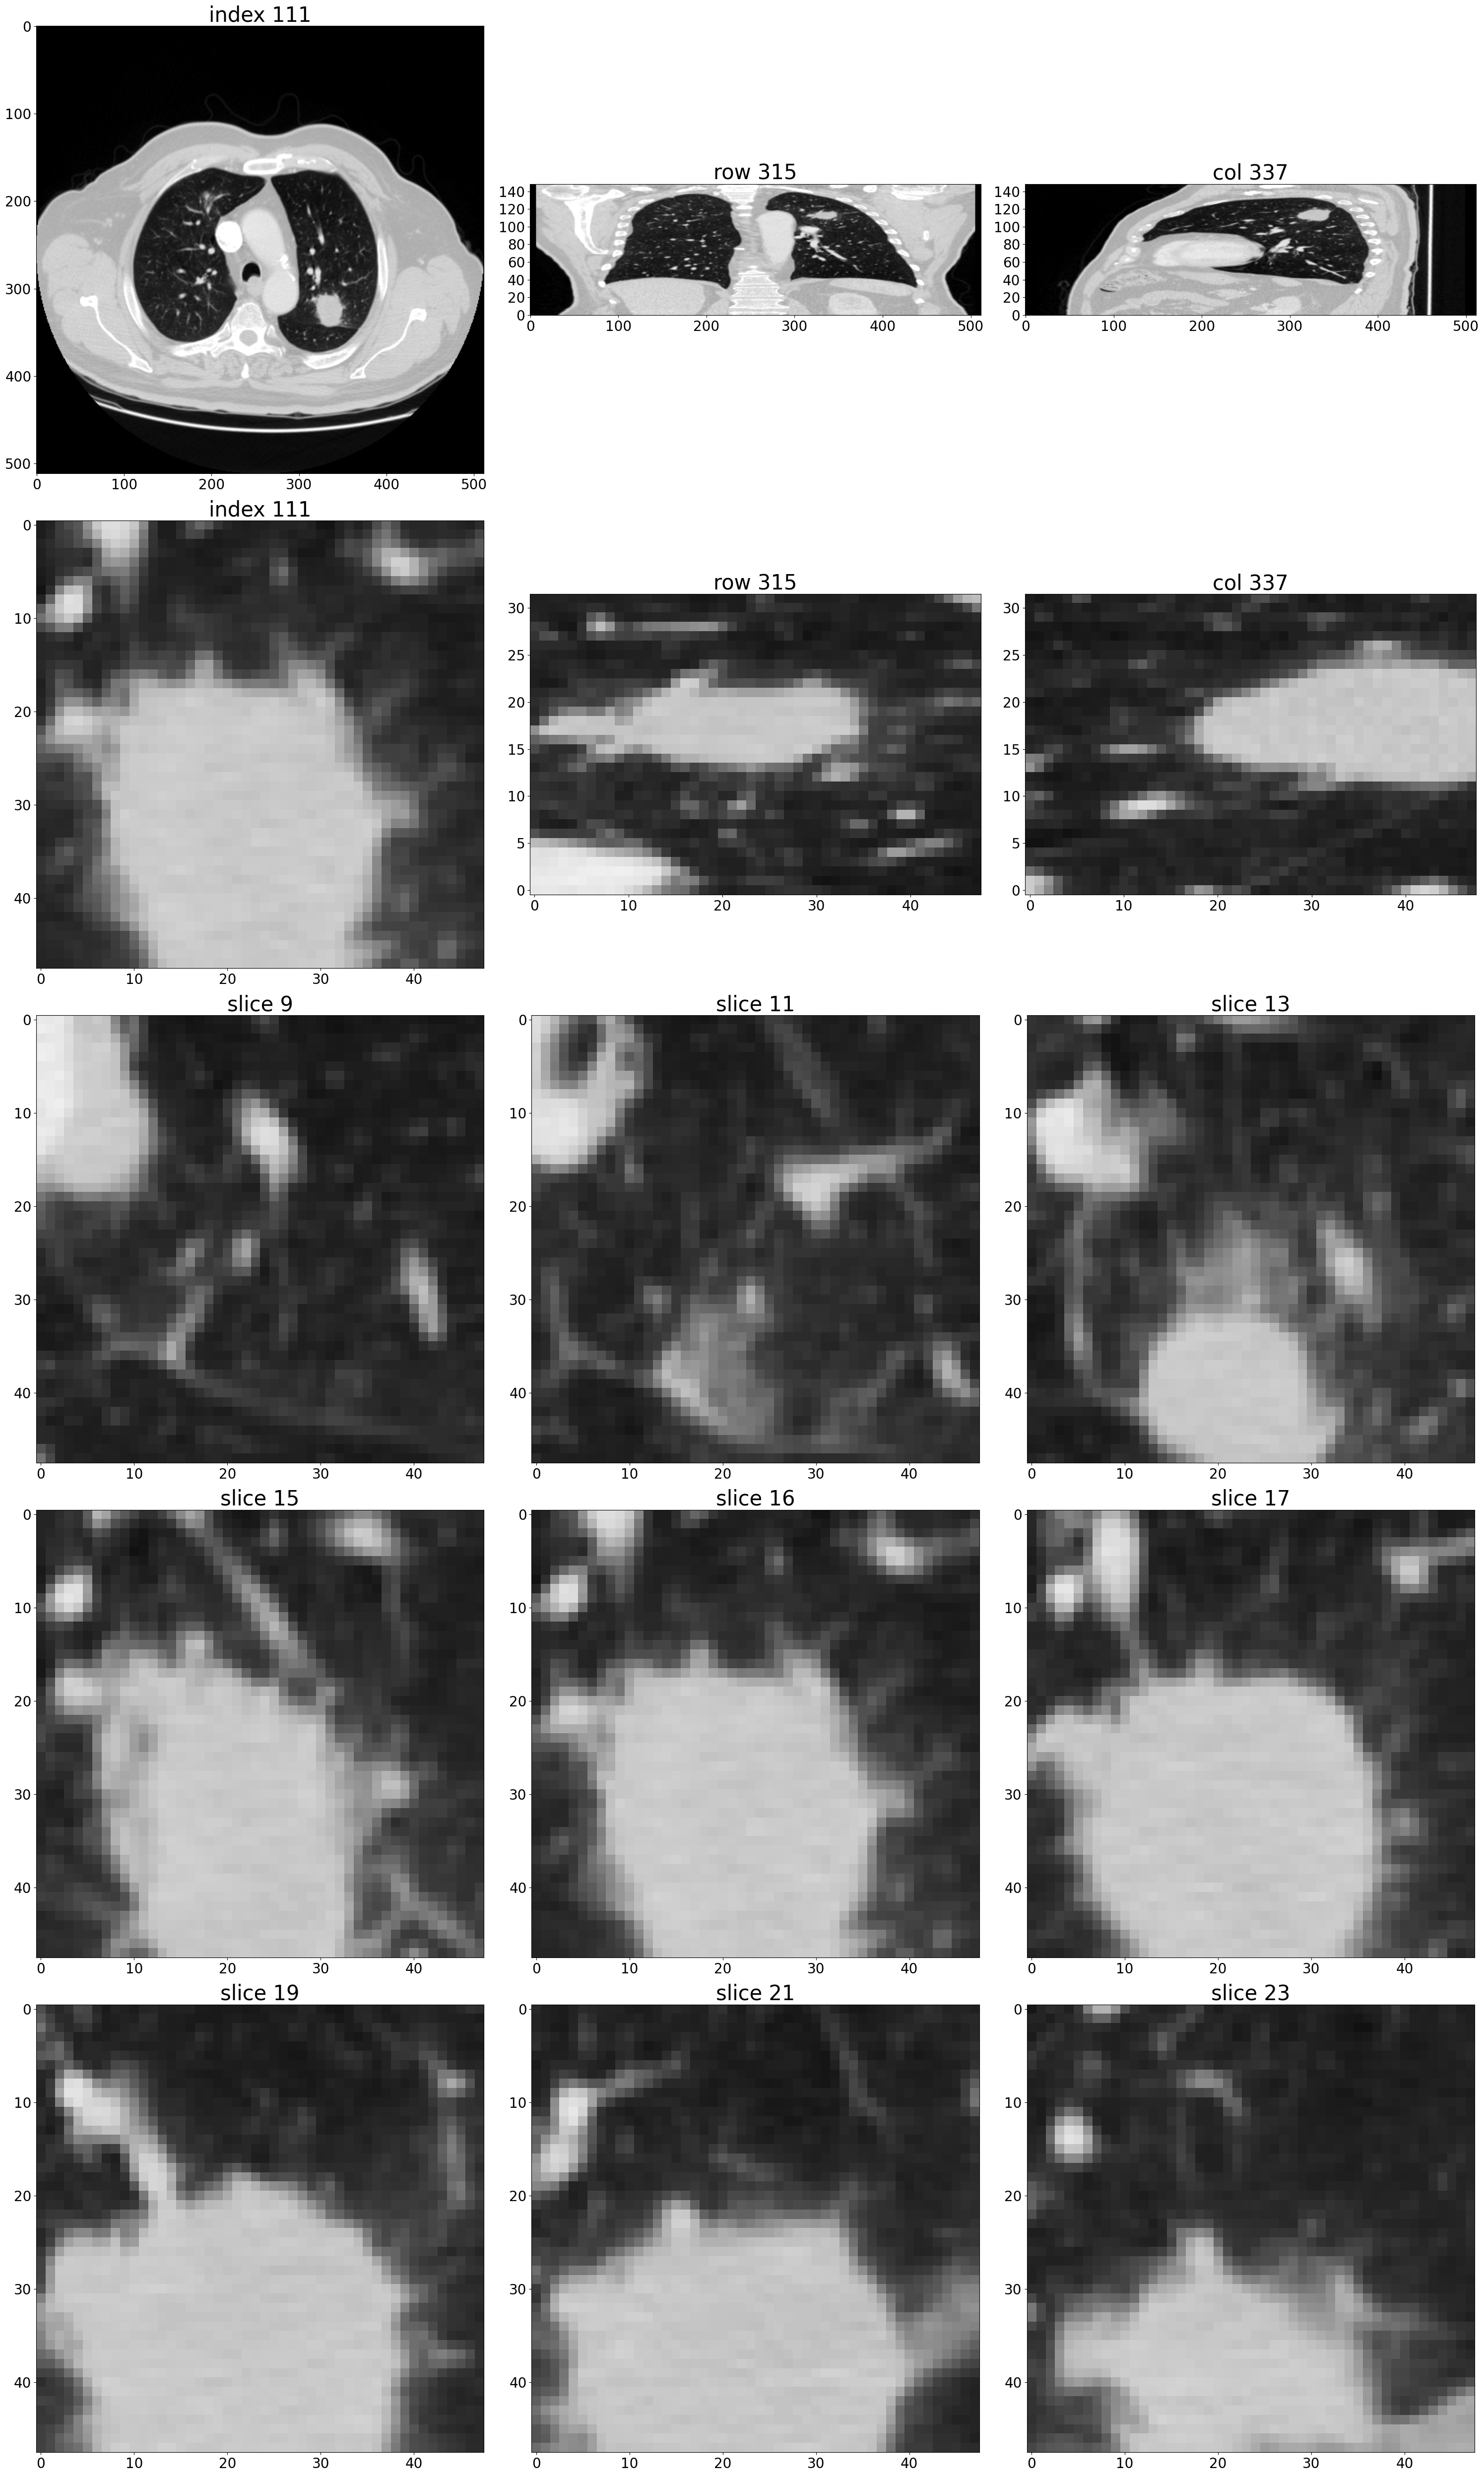

1.3.6.1.4.1.14519.5.2.1.6279.6001.112740418331256326754121315800 0 False [0, 1, 2, 3, 4, 5, 6]


In [9]:
positiveSample_list = findPositiveSamples()
series_uid = positiveSample_list[11][2]
showCandidate(series_uid)